# NORD POOL PORTFOLIO DESIGN

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from scipy.linalg import cho_factor, cho_solve, LinAlgError
from scipy.fft import fft, fftfreq
from scipy.stats import shapiro, skew, kurtosis, ttest_rel, normaltest,jarque_bera
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import json
import math

import requests 
from scipy.optimize import minimize, Bounds, LinearConstraint
from typing import Union, Sequence, Tuple

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Noordpool
The Nordic electricity market is represented by bidding zones cleared through the Nord Pool power exchange, including Norway (NO1–NO5), Sweden (SE1–SE4), Denmark (DK1–DK2), Finland (FI), and the Baltic countries (Estonia, Latvia, and Lithuania). These zones reflect physically deliverable price areas determined by internal transmission constraints and regional supply–demand conditions. All Nordic and Baltic bidding zones are integrated into the Single Day-Ahead Coupling (SDAC) mechanism, allowing cross-border capacity to be optimally allocated with Continental European markets while maintaining zone-specific prices whenever network congestion occurs.

For data compailingn, down links was used; 
+ https://data.nordpoolgroup.com/auction/day-ahead/prices?deliveryDate=2024-01-
+ https://www.energy-charts.info/charts/price_average/chart.htm?c=DE&l=en&utm_source=chatgpt.com&interval=day&year=2024

In [3]:
dfnp = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\Avrupa Market\Data\nordpool_and_epex.xlsx",sheet_name="NORDPOOL")
dfnp = dfnp.drop(columns=["Delivery Date (CET)","SYS"])

## PLOTS AND DESCRİBE

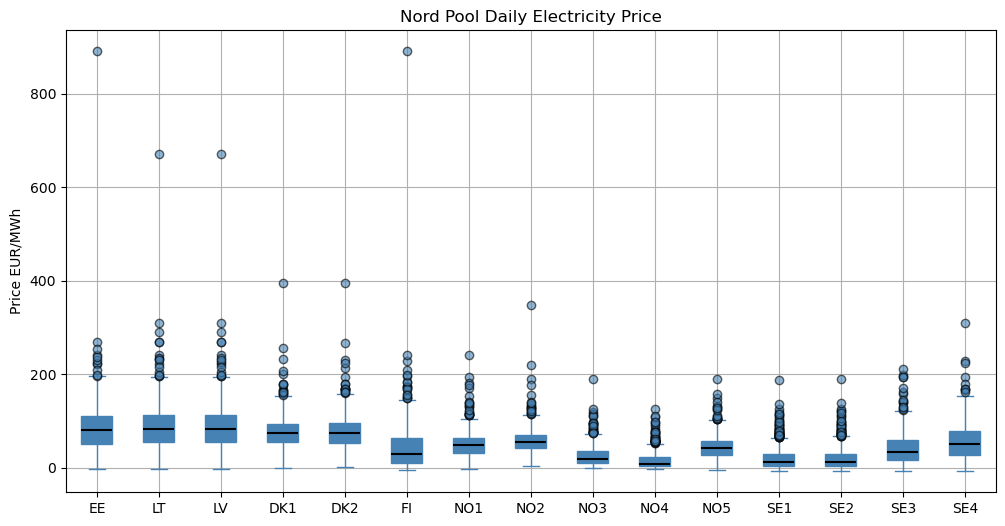

In [4]:
plt.figure(figsize=(12, 6)) 
ax = dfnp.boxplot(
         patch_artist=True,        # box'ların içini boyamak için şart
         boxprops=dict(facecolor="steelblue", color="steelblue"),
         medianprops=dict(color="black", linewidth=1.5),
         whiskerprops=dict(color="steelblue"),
         capprops=dict(color="steelblue"),
         flierprops=dict(marker='o', markerfacecolor='steelblue', alpha=0.6))
ax.set_ylabel("Price EUR/MWh")
ax.set_title("Nord Pool Daily Electricity Price")
plt.show()

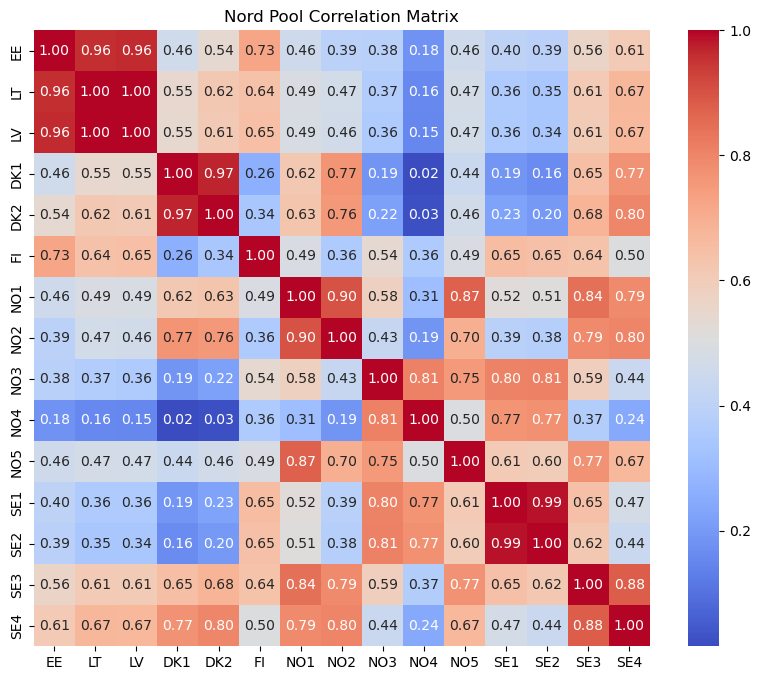

In [5]:
corr = dfnp.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Nord Pool Correlation Matrix")
plt.show()

In [6]:
dfnp.describe().T.style.format("{:.0f}")

,count,mean,std,min,25%,50%,75%,max
EE,731,84,54,-2,52,81,109,891
LT,731,86,50,-3,56,83,112,671
LV,731,87,50,-3,56,83,112,671
DK1,731,76,36,-0,54,75,94,395
DK2,731,77,37,1,53,75,96,395
FI,731,43,52,-5,9,29,64,891
NO1,731,50,28,-3,32,49,64,240
NO2,731,58,27,4,41,56,70,348
NO3,731,25,22,-1,9,18,35,189
NO4,731,16,18,-3,3,9,23,125


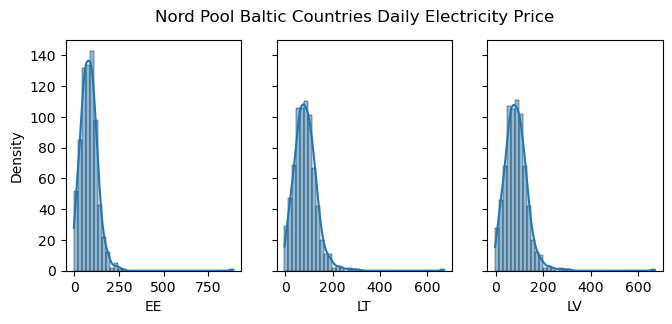

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(7.7, 3), sharey=True)
sns.histplot(dfnp["EE"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfnp["LT"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfnp["LV"], bins=40, kde=True, ax=axes[2])
axes[0].set_ylabel("Density")
fig.suptitle("Nord Pool Baltic Countries Daily Electricity Price", fontsize=12)
plt.show()

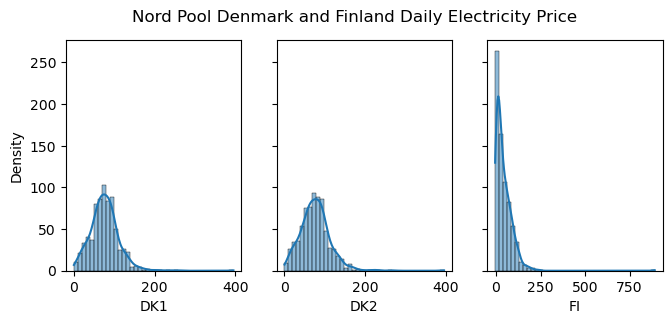

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(7.7, 3), sharey=True)
sns.histplot(dfnp["DK1"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfnp["DK2"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfnp["FI"], bins=40, kde=True, ax=axes[2])
axes[0].set_ylabel("Density")
fig.suptitle("Nord Pool Denmark and Finland Daily Electricity Price", fontsize=12)
plt.show()

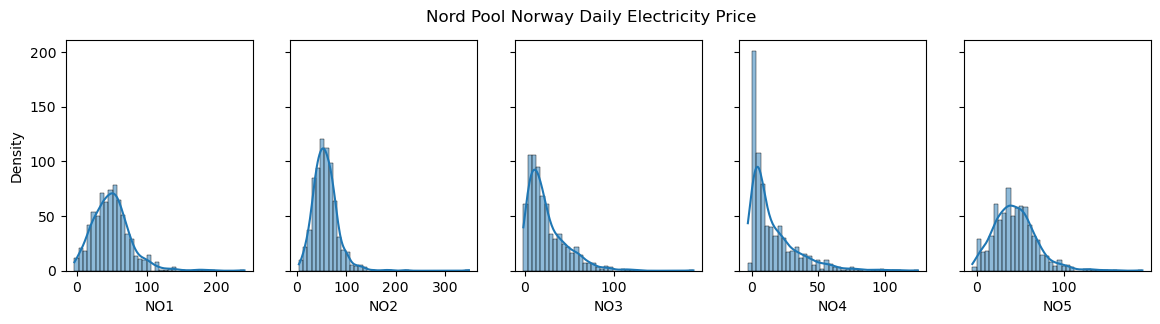

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3), sharey=True)
sns.histplot(dfnp["NO1"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfnp["NO2"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfnp["NO3"], bins=40, kde=True, ax=axes[2])
sns.histplot(dfnp["NO4"], bins=40, kde=True, ax=axes[3])
sns.histplot(dfnp["NO5"], bins=40, kde=True, ax=axes[4])
axes[0].set_ylabel("Density")
fig.suptitle("Nord Pool Norway Daily Electricity Price", fontsize=12)
plt.show()

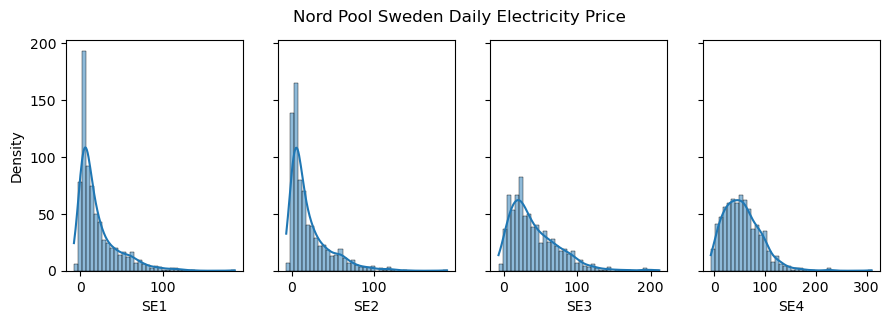

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(10.5, 3), sharey=True)
sns.histplot(dfnp["SE1"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfnp["SE2"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfnp["SE3"], bins=40, kde=True, ax=axes[2])
sns.histplot(dfnp["SE4"], bins=40, kde=True, ax=axes[3])
axes[0].set_ylabel("Density")
fig.suptitle("Nord Pool Sweden Daily Electricity Price", fontsize=12)
plt.show()

In [11]:
def stat(series):
    name = series.name             
    data = series.dropna().values   

    stat, p = shapiro(data)
    stat, pk2 = normaltest(data)
    stat, pjb = jarque_bera(data)

    print("values:", name)
    print("shapiro  p-value:", f"{p:.3f}")
    print("kare    p-value:", f"{pk2:.3f}")
    print("jarque  p-value:", f"{pjb:.3f}")

    print("Skewness value :", f"{skew(data):.3f}")
    print("Kurtosis value :", f"{kurtosis(data):.3f}")

    # --- Q-Q Plot ---
    st.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {name}")   
    plt.show() 

values: EE
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 4.952
Kurtosis value : 69.045


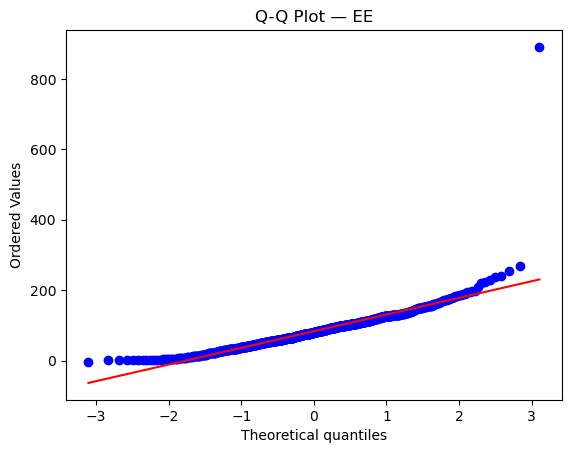

values: LT
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.736
Kurtosis value : 25.566


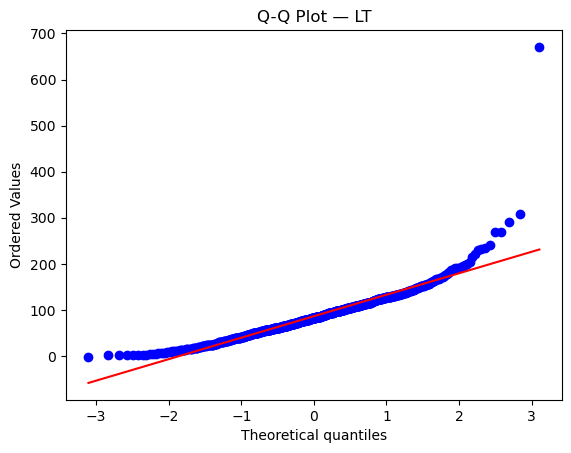

values: LV
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.748
Kurtosis value : 25.881


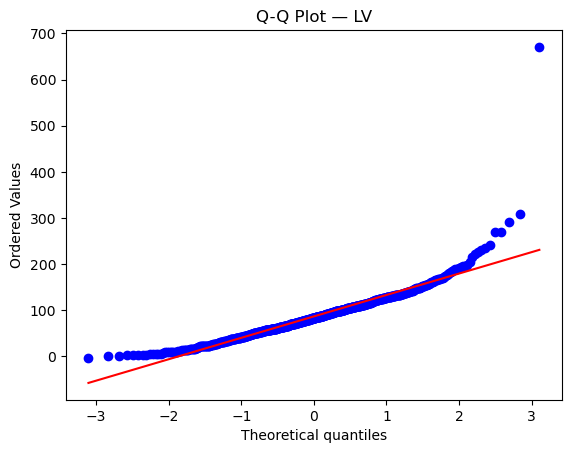

values: DK1
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.479
Kurtosis value : 9.630


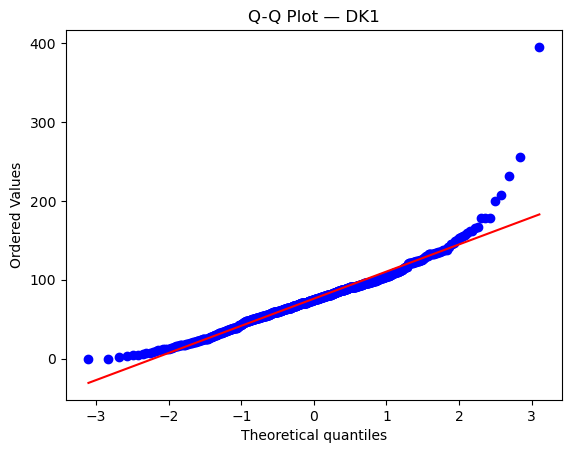

values: DK2
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.438
Kurtosis value : 8.416


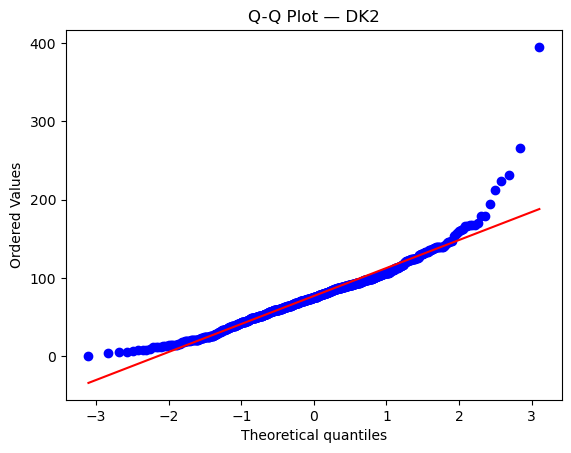

values: FI
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 6.681
Kurtosis value : 98.050


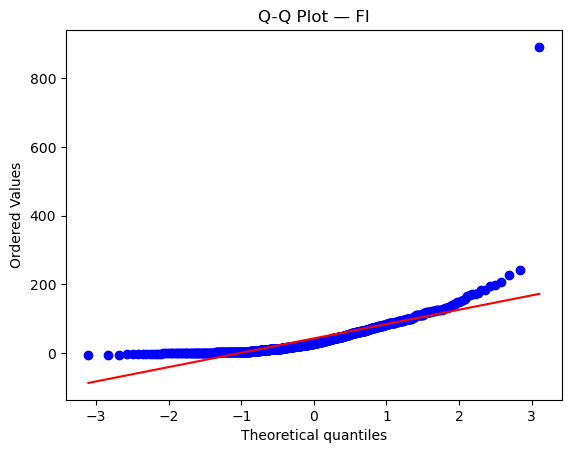

values: NO1
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.355
Kurtosis value : 5.061


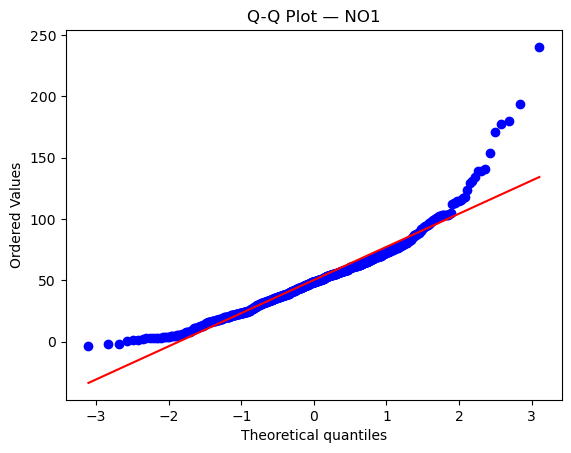

values: NO2
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.704
Kurtosis value : 21.852


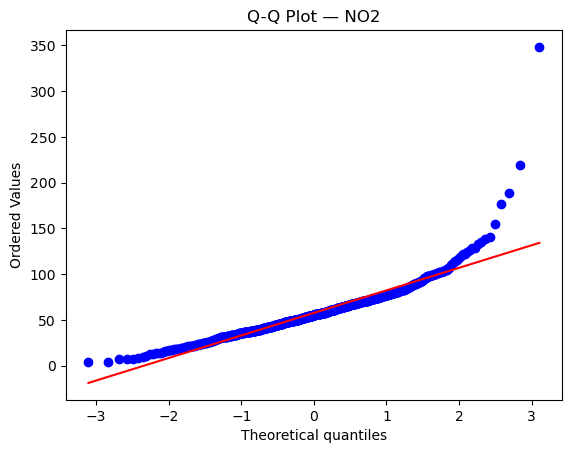

values: NO3
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.843
Kurtosis value : 5.666


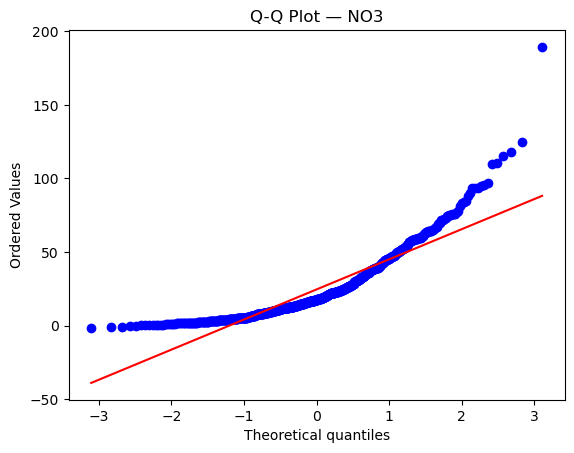

values: NO4
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.032
Kurtosis value : 5.257


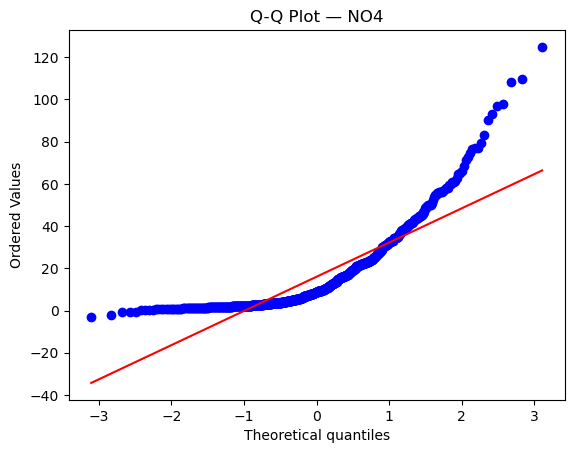

values: NO5
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.029
Kurtosis value : 2.866


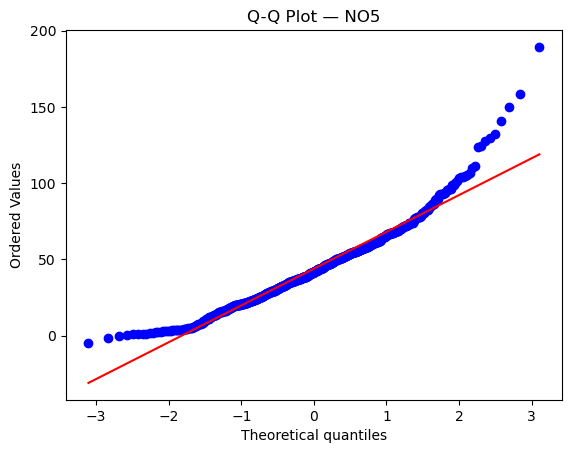

values: SE1
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.017
Kurtosis value : 5.348


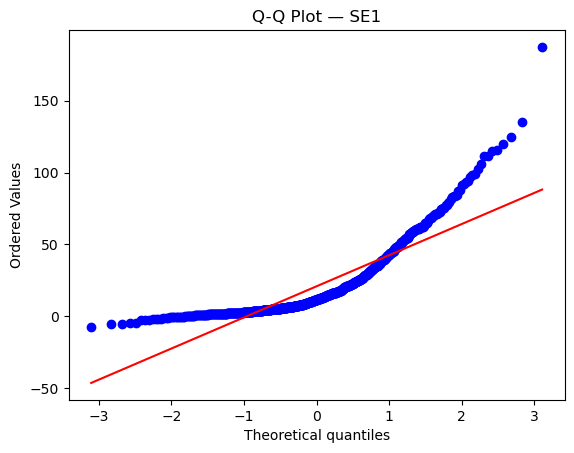

values: SE2
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.022
Kurtosis value : 5.500


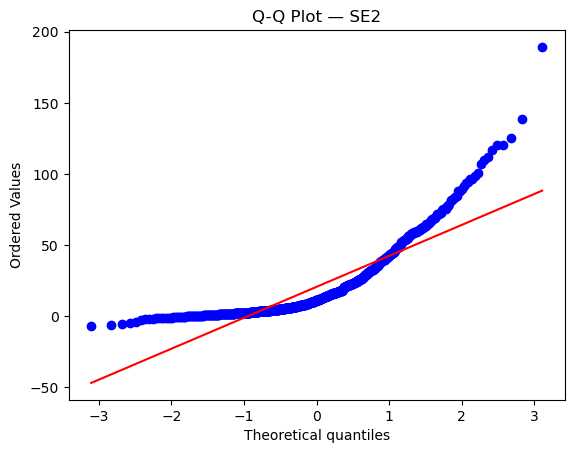

values: SE3
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.373
Kurtosis value : 2.712


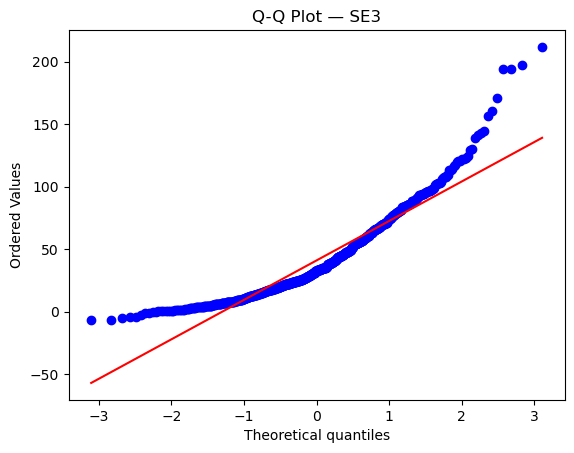

values: SE4
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.191
Kurtosis value : 3.785


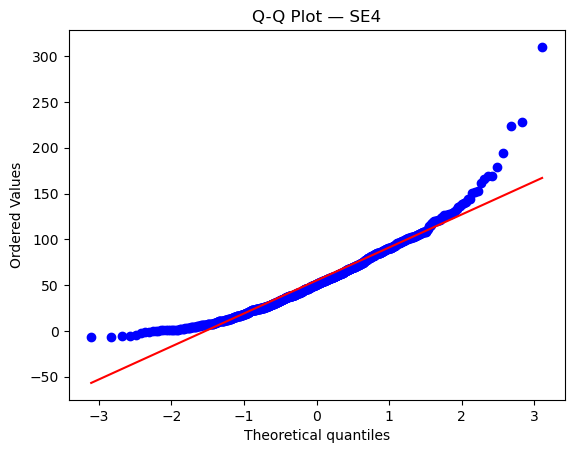

In [12]:
for col in dfnp.columns:
    stat(dfnp[col])

##  PORTFOLIO DESIGN

In [13]:
def optimalPortfoliononshort(
    df: pd.DataFrame,
    C: float,
    gamma: float,
    lower_bounds: Union[float, Sequence[float]] = 0.0,
    upper_bounds: Union[float, Sequence[float]] = 1.0,
    ridge: float = 1e-8,
) -> Tuple[pd.Series, float, float]:
    """
    Solve:  min_λ  C μ^T λ + γ C^2 λ^T Σ λ
            s.t.   1^T λ = 1,  lb ≤ λ ≤ ub
    df: price levels (rows=time, cols=sources). Returns (λ*, E[X], Var[X]).
    """
    if C <= 0 or gamma <= 0:
        raise ValueError("C and gamma must be > 0.")                              # risk katsayısı ve C >0 olmalı
    X = df.dropna(axis=1, how="all").dropna(axis=0, how="any").astype(float)      # Nan lar atılır
    if X.shape[0] < 2 or X.shape[1] < 1:
        raise ValueError("Not enough data.")                                      # Cov için boyutu minumum 2x2 olmalıdır

    mu = X.mean().to_numpy()                                                      # E[p]
    Sigma = X.cov(ddof=1).to_numpy()                                              # Cov[p], ddof=1 by default
    Sigma = 0.5 * (Sigma + Sigma.T) + ridge * np.eye(len(mu))                     # Symmetrize to dampen numerical asymmetry
    n = len(mu)                                                                   # mu boyutu bulundu

    # expand bounds to vectors
    lb = np.full(n, lower_bounds if np.isscalar(lower_bounds) else np.asarray(lower_bounds, float))  #lower bound
    ub = np.full(n, upper_bounds if np.isscalar(upper_bounds) else np.asarray(upper_bounds, float))  #Upper bound
    if lb.sum() > 1 + 1e-12 or ub.sum() < 1 - 1e-12:
        raise ValueError("Infeasible bounds: need sum(lb) ≤ 1 ≤ sum(ub).")                           #sum(lb) ≤ 1 ≤ sum(ub) şartını manuel test ediyor

    # feasible start: begin at lb, spread remaining mass toward ub
    w0 = lb.copy()                                         # ilk olarak ağırlıklar minimuma eşitleniyor
    rem = 1.0 - w0.sum()                                   # Eşitlik koşulundan yola çıkarak 1'den çıkarılıyor
    if rem > 0:                                            # Ağırlıklar bulunur
        room = np.maximum(ub - w0, 0.0)
        total = room.sum()
        if total > 0: w0 += rem * (room / total)           # toplamın 1 e eşit olduğu sağlanır
    w0 = np.clip(w0, lb, ub)                               # ağırlıkları (w) sınırlar içinde burakır

    def fun(w):  return C * mu @ w + gamma * (C**2) * (w @ Sigma @ w)  #fonksiyon f(w)=Cμ⊤w+γC2w⊤Σw amaç fonk  scaler
    def jac(w):  return C * mu + 2.0 * gamma * (C**2) * (Sigma @ w)    #jacobien  ∇f(w)=Cμ+2γC2Σw   1. Türev   (n,)
    def hess(w): return 2.0 * gamma * (C**2) * Sigma                   #hessian   ∇2f(w)=2γC2Σ      2. Türev   (n,n)

    cons = [LinearConstraint(np.ones((1, n)), 1.0, 1.0)]                # w vektörü ve sınırlar toplamlar 1 e eşit
    bnds = Bounds(lb, ub)                                               # Sınırlar 
    opt  = minimize(fun, w0, method="trust-constr", jac=jac, hess=hess, # Optimizasyon tam olarak burda yapılır ve newton tabanlıdır.
                   bounds=bnds, constraints=cons,
                   options={"maxiter": 500, "gtol": 1e-10, "xtol": 1e-12, "verbose": 0})  
    #gtol=1e-10	Gradyan normu bu değerden küçükse dur.
    #xtol=1e-12	w vektöründeki değişim bu değerden küçükse dur.
    #maxiter=500	Maksimum iterasyon sayısı.
    #verbose=0	Çıktı susturulmuş. 2 yapsan her adımı loglar.
    
    
    if not opt.success:
        raise RuntimeError(f"Optimization failed: {opt.message}")  # algoritmanın neden durduğunu açıklayan yazı "opt.***" gibi türev bilgi verilebilir.

    w = pd.Series(opt.x, index=X.columns, name="No-Short")
    E = C * float(mu @ opt.x)
    V = (C**2) * float(opt.x.T @ Sigma @ opt.x)
    return w, E, V

In [14]:
def optimalPortfolio(df: pd.DataFrame, C: float, gamma: float) -> Tuple[pd.Series, float, float]:
    """
    Interior mean–variance optimizer for procurement weights λ under:
        min_{λ}  C μ^T λ + γ C^2 λ^T Σ λ   s.t.  1^T λ = 1

    Parameters
    ----------
    df : pd.DataFrame
        Historical unit prices (not returns): rows = time, columns = instruments.
        NaNs are dropped row-wise before estimation.
    C : float
        Deterministic total energy requirement (> 0).
    gamma : float
        Risk aversion parameter on variance term (> 0).

    Returns
    -------
    np.ndarray
        The interior optimal weight vector λ* (length = number of columns in df).

    Notes
    -----
    - This returns the *interior* solution, which requires Σ ≻ 0 (SPD).
      If Σ is singular (e.g. a riskless/constant-price instrument or perfect collinearity),
      a ValueError is raised. In that case, remove/merge collinear sources or solve
      the full KKT system with inequality constraints as appropriate.
    - Uses a Cholesky factorization; no explicit matrix inverses are formed.
    """

    #Girdilerden kaynaklı anlamsız hataları verir
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame of historical unit prices.")
    if C <= 0:
        raise ValueError("C must be strictly positive.")
    if gamma <= 0:
        raise ValueError("gamma must be strictly positive.")


    # Nan varsa düşürür ve cov için en az iki satıra ihtiyaç var. 
    df_clean = df.dropna(how="any").astype(float)
    if df_clean.shape[0] < 2 or df_clean.shape[1] < 1:
        raise ValueError("Not enough data after dropping NaNs to estimate μ and Σ.")
    

    mu = df_clean.mean(axis=0).to_numpy()                 # E[p] 
    Sigma = df_clean.cov().to_numpy()                     # Cov[p], ddof=1 by default
    Sigma = 0.5 * (Sigma + Sigma.T)                       # Symmetrize to dampen numerical asymmetry
    n = Sigma.shape[0]                                    # cov boyutu bulundu
    ones = np.ones(n)                                     # Birim vektör (cov boyutunda)

    # Cholesky-based solves to avoid explicit inversion ----- Bu blok, Σ’nın sağlıklı olduğunu garanti altına alıyor
    try:
        cF = cho_factor(Sigma, lower=True, check_finite=True)
    except LinAlgError as e:
        raise ValueError("Covariance matrix Σ is not SPD; interior solution undefined.") from e

    # Solve Σ x = 1 and Σ y = μ
    Sigma_inv_1 = cho_solve(cF, ones)                    #Σ^{−1} * 1
    Sigma_inv_mu = cho_solve(cF, mu)                     #Σ^{−1} * μ

    denom = float(ones @ Sigma_inv_1)                    # 1^T * Σ^{-1} * 1
    if denom <= 0 or not np.isfinite(denom):
        raise ValueError("Numerical issue: 1^T Σ^{-1} 1 must be positive and finite.")

    eta_num = 2.0 * gamma * (C**2) + C * float(ones @ Sigma_inv_mu)    # 2γC^{2} + C1^{⊤}Σ^{−1}μ
    eta = eta_num / denom                                              # [ 2γC^{2} + C1^{⊤}Σ^{−1}μ ] / [ 1^T * Σ^{-1} * 1] 

    # λ* = (1/(2 γ C^2)) [ Σ^{-1}(η 1 - C μ) ] = (1/(2 γ C^2)) (η Σ^{-1}1 - C Σ^{-1}μ)
    lam = (eta * Sigma_inv_1 - C * Sigma_inv_mu) / (2.0 * gamma * (C**2))
    # lam = (C * Sigma_inv_mu - eta * Sigma_inv_1) / (2.0 * gamma * (C**2))

    
    # Optional: enforce the affine constraint numerically (tiny adjustment)
    lam += (1.0 - lam.sum()) * (Sigma_inv_1 / denom)                   # 1^{⊤} * λ = 1 kısıtını mikro ayarla geri oturtur düzeltme amaçlıdır.

    w = pd.DataFrame(lam, index=df.columns )
    E = C * float(mu @ lam)
    V = (C**2) * float(lam @ Sigma @ lam)
    
    return w, E, V 

In [15]:
def results(data):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="scipy")

    #######################  W ##########################################################################################################
    #####################################################################################################################################
    prices = data.dropna()
    prices.reset_index(drop=True, inplace=True)

    C=10000
    gamma= 1  #risk katsayısı
    n = prices.shape[1]                                    # cov boyutu bulundu
    upper_bounds = np.full(n, 0.2)  
    lower_bounds = np.full(n, -0.2) 
        
    w0, E0, V0 = optimalPortfoliononshort(prices, C=C, gamma=gamma )
    w1, E1, V1 = optimalPortfoliononshort(prices, C=C, gamma=gamma,  upper_bounds=upper_bounds)
    w2, E2, V2 = optimalPortfoliononshort(prices, C=C, gamma=gamma,  upper_bounds=upper_bounds , lower_bounds=lower_bounds)
    w3, E3, V3 =  optimalPortfolio(prices,C,gamma)
    
    w0_df = w0.copy()
    w1_df = w1.copy()
    w2_df = w2.copy()
    w3_df = w3.copy()
    
    weights_df = pd.concat([w0_df, w1_df, w2_df,w3_df], axis=1)
    weights_df.columns = ["P1 non-short","P2 non-short limited UB", "P3 with limited UB-LB","P4 with short"]
    weights_df = weights_df.round(2)
    
    plt.figure(figsize=(10,8))
    sns.heatmap(weights_df, annot=True, fmt=".2f", cmap="coolwarm" , square=True)
    plt.title("Weight Matrix")
    plt.show()

    #######################  MONTE CARLO  ###############################################################################################
    #####################################################################################################################################

    mu = prices.mean().to_numpy()
    Sigma = prices.cov(ddof=1).to_numpy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    
    lam1 = weights_df["P1 non-short"].to_numpy()
    lam2 = weights_df["P2 non-short limited UB"].to_numpy()
    lam3 = weights_df["P3 with limited UB-LB"].to_numpy()
    lam4 = weights_df["P4 with short"].to_numpy()     
    
    n_sim = 10_000
    rng = np.random.default_rng(42)
    p = rng.multivariate_normal(mu, Sigma, size=n_sim)  # ortalama maliyet üretildi. Rastgele ama mantıklı. 
    
    # Toplam maliyet
    X1 = C * (p @ lam1) #P1 non-short
    X2 = C * (p @ lam2) #P2 non-short limited UB
    X3 = C * (p @ lam3) #P3 with limited UB-LB
    X4 = C * (p @ lam4) #P4 with short

    # İstatistikler
    
    P1E, P1R = float(X1.mean()), float(X1.std(ddof=0))
    P2E, P2R = float(X2.mean()), float(X2.std(ddof=0))
    P3E, P3R = float(X3.mean()), float(X3.std(ddof=0))
    P4E, P4R = float(X4.mean()), float(X4.std(ddof=0))

    #######################   E V CALCULATION ###########################################################################################
    #####################################################################################################################################
    
    perf_mc_df = pd.DataFrame({
        "Expected Cost (MC)": [P1E, P2E, P3E, P4E],
        "Expected Cost": [E0, E1, E2, E3], 
        "Risk (Std, MC)":     [P1R, P2R, P3R, P4R],
        "Risk (Std)": [np.sqrt(V0),np.sqrt(V1), np.sqrt(V2),np.sqrt(V3)]}, 
        index=["P1 Non-Short", "P2 Non-Short UB", "P3 UB-LB", "P4 With Short"])
    display(perf_mc_df.style.format("{:,.0f}"))
    
    return {
    "prices": prices,
    "weights_df": weights_df,
    "perf_mc_df": perf_mc_df,
    "w0": w0, "w1": w1, "w2": w2, "w3": w3,
    "E0": E0, "E1": E1, "E2": E2, "E3": E3,
    "V0": V0, "V1": V1, "V2": V2, "V3": V3,
    }


Nord Pool


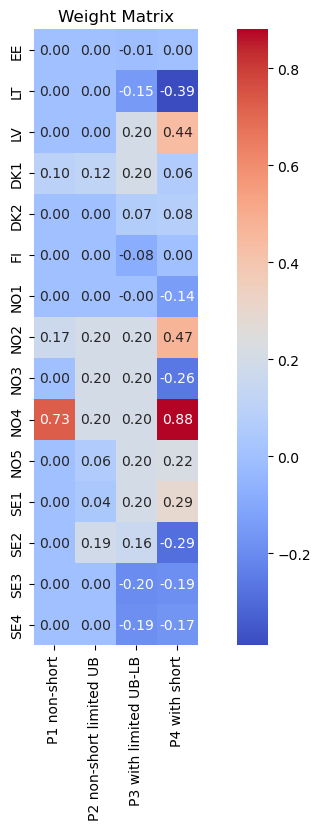

,Expected Cost (MC),Expected Cost,"Risk (Std, MC)",Risk (Std)
P1 Non-Short,"293,826","292,856","163,282","161,704"
P2 Non-Short UB,"365,681","357,188","191,249","186,568"
P3 UB-LB,"381,050","378,104","170,020","167,869"
P4 With Short,"356,277","354,284","148,992","147,297"


In [16]:
print("Nord Pool")
out = results(dfnp)

# Efficient Frontier 

In [17]:
prices=dfnp
C=10000
gamma = 1

In [18]:
# =========================================================
# EFFICIENT FRONTIER - 4 PORTFOLIO DESIGNS
# Existing objects assumed:
# prices, Cc
# optimalPortfoliononshort(...)
# optimalPortfolio(...)
# =========================================================

n = prices.shape[1]

# Bounds used in your previous setup
ub_02 = np.full(n, 0.2)
lb_m02 = np.full(n, -0.2)

ub_03 = np.full(n, 3)
lb_m03 = np.full(n, -3)

# Wider gamma grid -> more points on the frontier
gamma_grid = np.logspace(-5, 1, 30)

def build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0):
    rows = []

    for g in gamma_grid:
        try:
            w, E, V = optimalPortfoliononshort(
                prices,
                C=C,
                gamma=float(g),
                lower_bounds=lower_bounds,
                upper_bounds=upper_bounds
            )
            rows.append([float(g), float(np.sqrt(V)), float(E)])
        except Exception:
            pass

    df_front = pd.DataFrame(rows, columns=["gamma", "risk", "cost"])
    df_front = df_front.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicate risk values can break the visual shape a bit
    df_front = df_front.sort_values("risk").drop_duplicates(subset="risk")

    return df_front


def build_frontier_short(prices, C, gamma_grid):
    rows = []

    for g in gamma_grid:
        try:
            w, E, V = optimalPortfolio(
                prices,
                C=C,
                gamma=float(g)
            )
            rows.append([float(g), float(np.sqrt(V)), float(E)])
        except Exception:
            pass

    df_front = pd.DataFrame(rows, columns=["gamma", "risk", "cost"])
    df_front = df_front.replace([np.inf, -np.inf], np.nan).dropna()
    df_front = df_front.sort_values("risk").drop_duplicates(subset="risk")

    return df_front


def get_current_portfolios(prices, C, gamma_point):
    n = prices.shape[1]
    ub = np.full(n,  0.2)
    lb = np.full(n, -0.2)
    ub1 = np.full(n,  3)
    lb1 = np.full(n, -3)
    
    w1, E1, V1 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point)
    w2, E2, V2 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point, upper_bounds=ub)
    w3, E3, V3 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point, lower_bounds=lb,  upper_bounds=ub)
    w4, E4, V4 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point, lower_bounds=lb1, upper_bounds=ub1)

    pts = pd.DataFrame({
        "Portfolio": [
            "P1 Non-Short",
            "P2 Non-Short Limited UB",
            "P3 Limited LB-UB",
            "P4 With Short"
        ],
        "risk": [
            float(np.sqrt(V1)),
            float(np.sqrt(V2)),
            float(np.sqrt(V3)),
            float(np.sqrt(V4))
        ],
        "cost": [
            float(E1),
            float(E2),
            float(E3),
            float(E4)
        ]
    })

    return pts

In [19]:
# ---------- Build frontiers ----------
front1 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0)
front2 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=ub_02)
front3 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=lb_m02, upper_bounds=ub_02)
front4 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=lb_m03, upper_bounds=ub_03)

# Choose one gamma to highlight current portfolio points
gamma_point = 1.0
pts = get_current_portfolios(prices, C, gamma_point)

# ---------- Check how many valid points each frontier has ----------
print("P1 valid points:", len(front1))
print("P2 valid points:", len(front2))
print("P3 valid points:", len(front3))
print("P4 valid points:", len(front4))

P1 valid points: 30
P2 valid points: 30
P3 valid points: 30
P4 valid points: 30


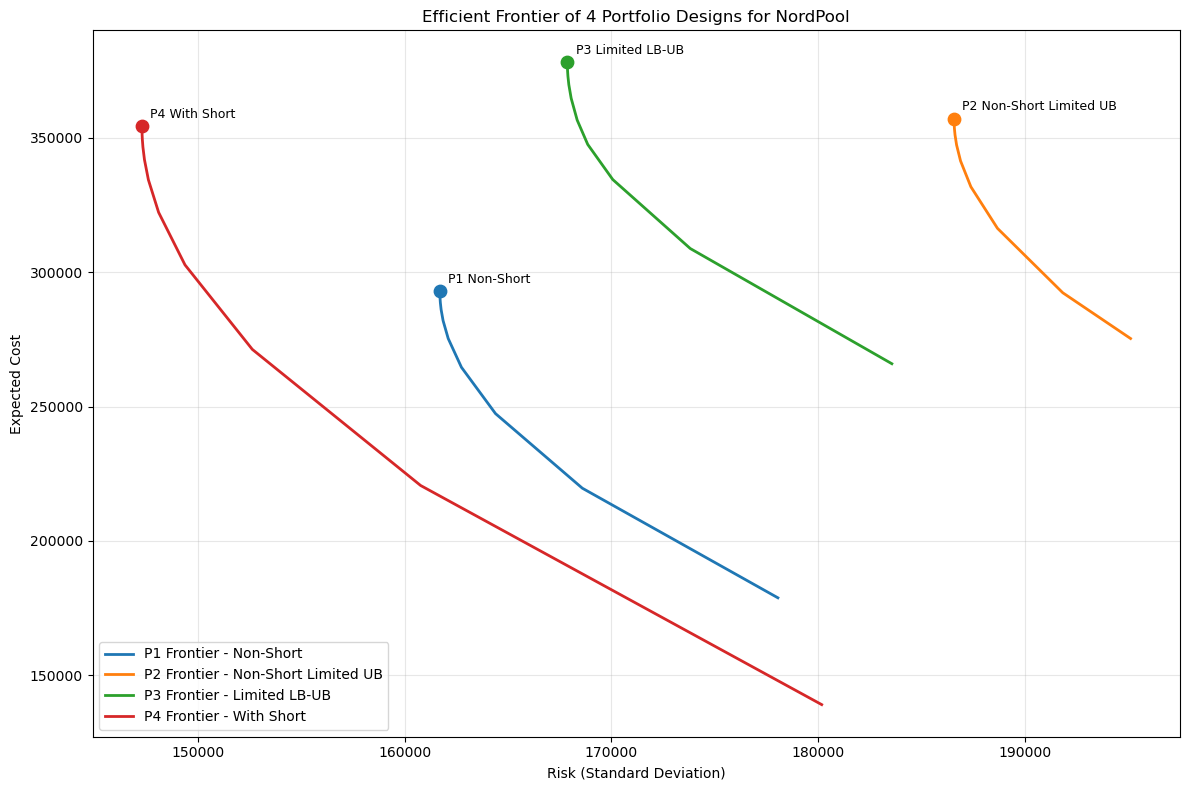

In [20]:
# ---------- Plot ----------
plt.figure(figsize=(12, 8))

if len(front1) > 1:
    plt.plot(front1["risk"], front1["cost"], linewidth=2, label="P1 Frontier - Non-Short")
if len(front2) > 1:
    plt.plot(front2["risk"], front2["cost"], linewidth=2, label="P2 Frontier - Non-Short Limited UB")
if len(front3) > 1:
    plt.plot(front3["risk"], front3["cost"], linewidth=2, label="P3 Frontier - Limited LB-UB")
if len(front4) > 1:
    plt.plot(front4["risk"], front4["cost"], linewidth=2, label="P4 Frontier - With Short")

# highlight current selected gamma portfolios
for _, row in pts.iterrows():
    plt.scatter(row["risk"], row["cost"], s=80)
    plt.annotate(
        row["Portfolio"],
        (row["risk"], row["cost"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Expected Cost")
plt.title("Efficient Frontier of 4 Portfolio Designs for NordPool")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# HEDGE 

In [16]:
dfhe = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\nordpool_and_epex.xlsx",sheet_name="F")
dfhe = dfhe.drop(columns=["Delivery Date (CET)"])
F = dfhe["SYS"]

In [17]:
w0 = out["w0"]
w1 = out["w1"]
w2 = out["w2"]
w3 = out["w3"]

In [18]:
S_dict = {
    "P1 non-short": (dfnp * w0.squeeze()).sum(axis=1),
    "P2 non-short limited UB": (dfnp * w1.squeeze()).sum(axis=1),
    "P3 with limited UB-LB": (dfnp * w2.squeeze()).sum(axis=1),
    "P4 with short": (dfnp * w3.squeeze()).sum(axis=1),
}

In [19]:
C = 10000
rows = []
for name, S in S_dict.items():
    df_h = pd.concat([S.rename("S"), F.rename("F")], axis=1).dropna() # --- Align S ve F (aynı index, NaN drop) ---
   
    d = df_h.diff().dropna()     # --- MVHR hedge ratio: h = Cov(dS,dF)/Var(dF) ---
    h = d["S"].cov(d["F"]) / d["F"].var()

    
    X_unhedged = C * df_h["S"]   # --- Cost series ---
    X_hedged   = C * df_h["S"] - (h * C) * (df_h["F"] - df_h["F"].iloc[0])

    
    E_un  = X_unhedged.mean()     # --- Metrics ---
    Std_un = X_unhedged.std(ddof=0)
    E_h   = X_hedged.mean()
    Std_h = X_hedged.std(ddof=0)

    rr = 100 * (1 - Std_h / Std_un)  # risk reduction %
    rows.append([name, float(h), E_un, E_h, Std_un,  Std_h, rr])

# --- 3) Results table ---
hedge_results = pd.DataFrame(rows, columns=[
    "Portfolio", "h*", "E (Unhedged)",  "E (Hedged)", "Std (Unhedged)", "Std (Hedged)", "Risk Reduction %"
]).set_index("Portfolio")
display(hedge_results.style
        .format("{:,.0f}", subset=["E (Unhedged)","Std (Unhedged)","E (Hedged)","Std (Hedged)"])
        .format("{:,.2f}", subset=["h*"])
        .format("{:,.2f}", subset=["Risk Reduction %"]))


,h*,E (Unhedged),E (Hedged),Std (Unhedged),Std (Hedged),Risk Reduction %
Portfolio,,,,,,
P1 non-short,0.45,"292,856","310,067","161,593","98,933",38.78
P2 non-short limited UB,0.63,"357,188","381,659","186,440","75,941",59.27
P3 with limited UB-LB,0.42,"378,104","394,525","167,754","110,751",33.98
P4 with short,0.28,"354,284","365,215","147,196","118,111",19.76
